In [2]:
import xgboost
print(xgboost.__version__)

3.4.1


# Customer Churn Prediction

## Phase 6 — Model Training & Comparison

C:\Users\ckaus\AppData\Local\Temp\ipykernel_12680\791886779.py:51: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(


Numerical features:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

Categorical features:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Training Logistic Regression...
Training Random Forest...
Training XGBoost...
Training completed.


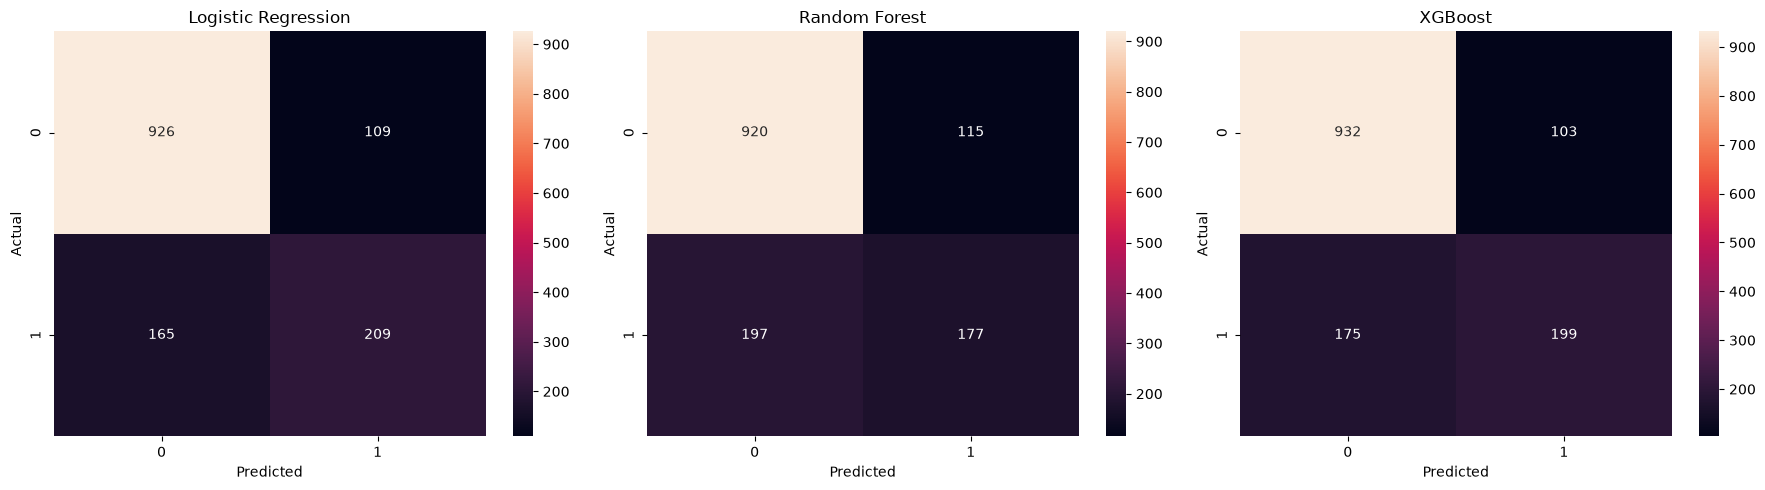

Logistic Regression
              precision    recall  f1-score   support

    No Churn       0.85      0.89      0.87      1035
       Churn       0.66      0.56      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409

Random Forest
              precision    recall  f1-score   support

    No Churn       0.82      0.89      0.86      1035
       Churn       0.61      0.47      0.53       374

    accuracy                           0.78      1409
   macro avg       0.71      0.68      0.69      1409
weighted avg       0.77      0.78      0.77      1409

XGBoost
              precision    recall  f1-score   support

    No Churn       0.84      0.90      0.87      1035
       Churn       0.66      0.53      0.59       374

    accuracy                           0.80      1409
   macro avg       0.75      0.72      0.73      1409
weighted avg       0.79      0.8

<Figure size 1000x700 with 0 Axes>

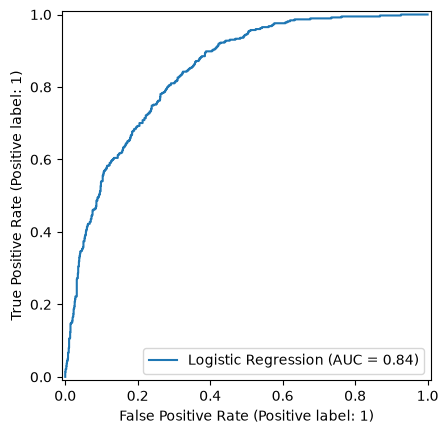

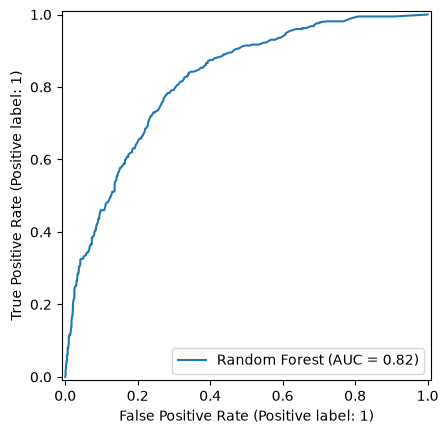

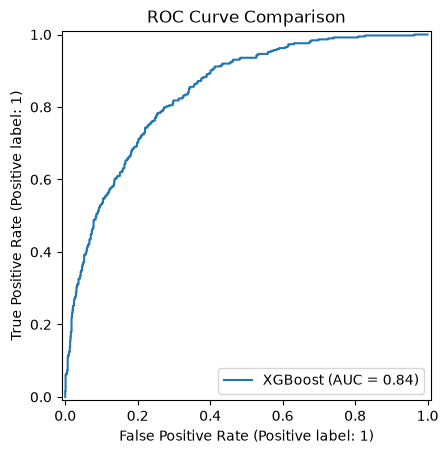

<Figure size 1000x700 with 0 Axes>

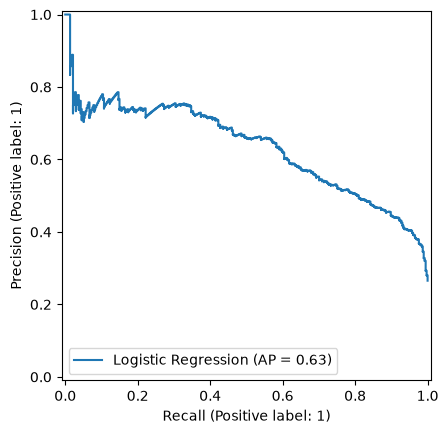

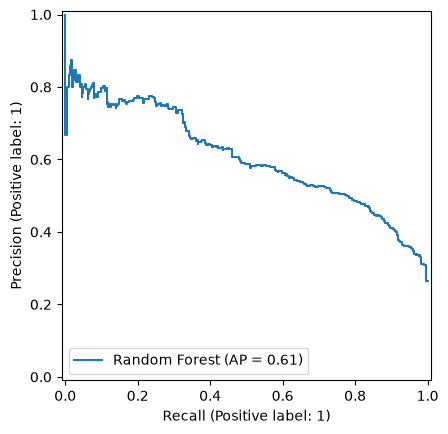

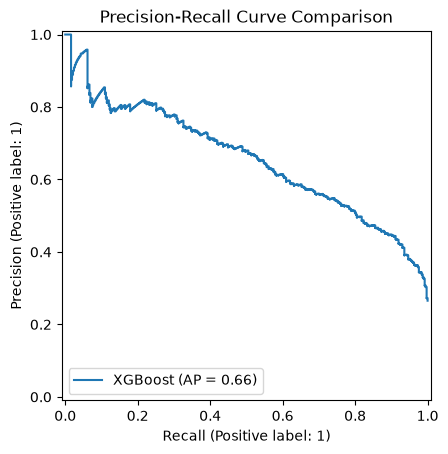

Train F1: 0.6971473915094369
Validation F1: 0.583070162464465


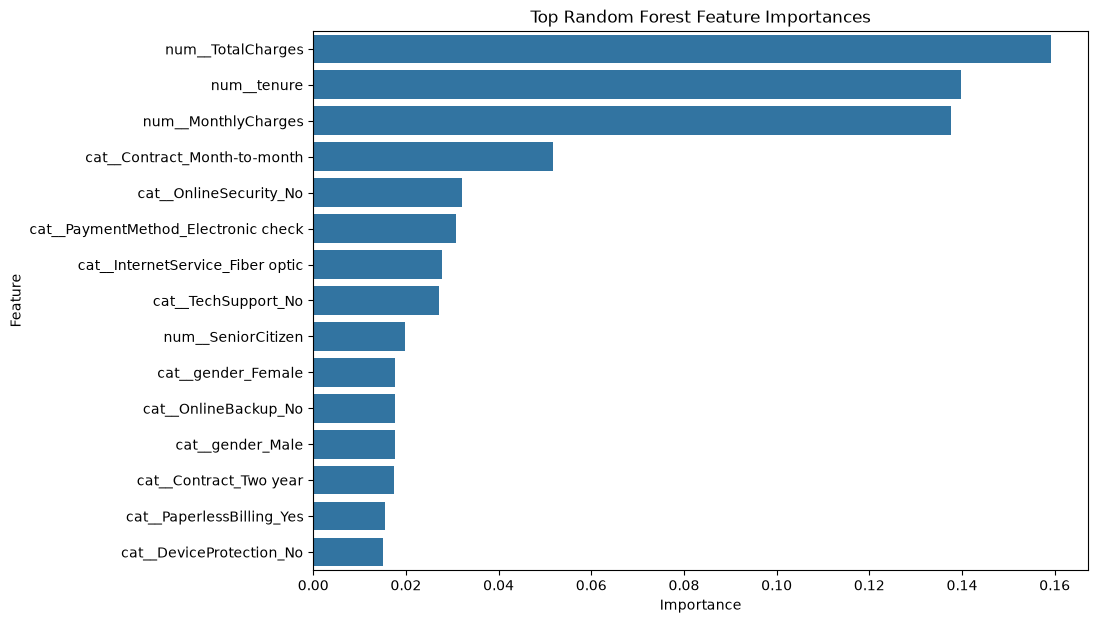

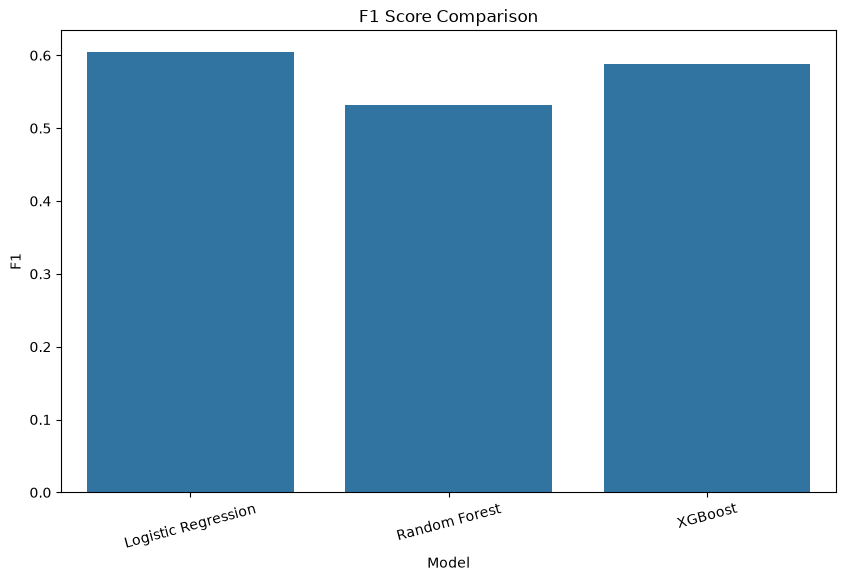

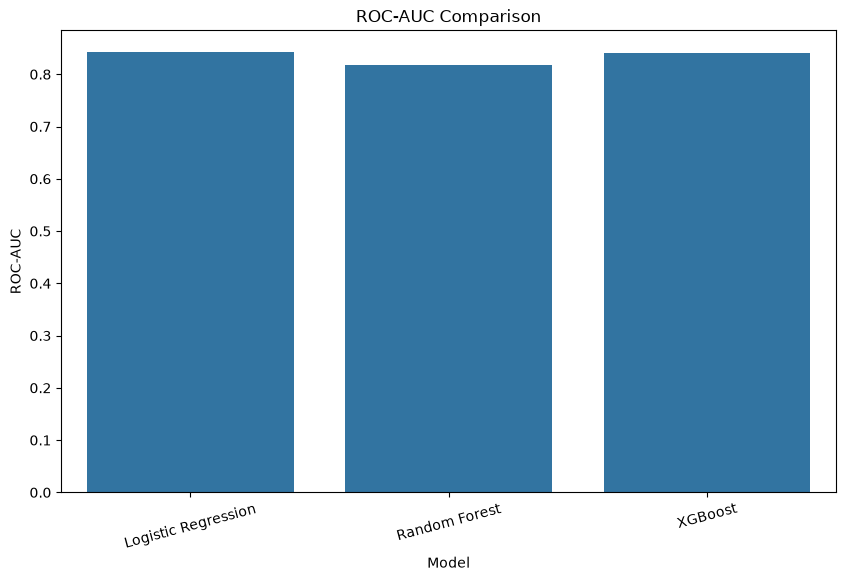

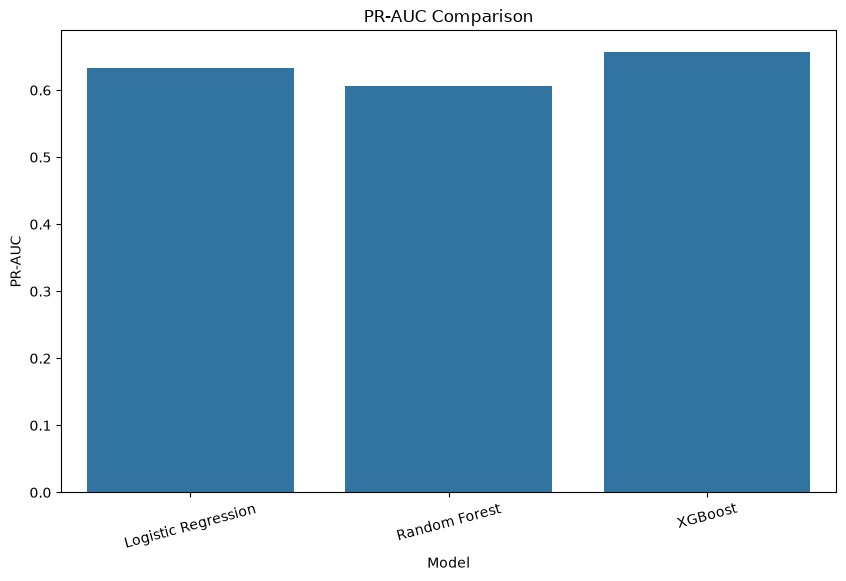

['../models/xgboost_baseline.joblib']

In [16]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay,
    PrecisionRecallDisplay
)
df = pd.read_csv(
    "../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv"
)
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)
y = df["Churn"].map({
    "No": 0,
    "Yes": 1
})
X = df.drop(
    columns=["Churn", "customerID"]
)
numeric_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numerical features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

numeric_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer,
            numeric_features
        ),
        (
            "cat",
            categorical_transformer,
            categorical_features
        )
    ]
)

logistic_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000
            )
        )
    ]
)

random_forest_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=300,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

xgb_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "classifier",
            XGBClassifier(
                n_estimators=300,
                learning_rate=0.05,
                max_depth=4,
                subsample=0.8,
                colsample_bytree=0.8,
                random_state=42,
                eval_metric="logloss",
                n_jobs=-1
            )
        )
    ]
)

models = {
    "Logistic Regression": logistic_model,
    "Random Forest": random_forest_model,
    "XGBoost": xgb_model
}

for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train)

print("Training completed.")

def evaluate_model(model, X_test, y_test):

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    metrics = {
        "Accuracy": accuracy_score(
            y_test,
            y_pred
        ),
        "Precision": precision_score(
            y_test,
            y_pred,
            zero_division=0
        ),
        "Recall": recall_score(
            y_test,
            y_pred,
            zero_division=0
        ),
        "F1": f1_score(
            y_test,
            y_pred,
            zero_division=0
        ),
        "ROC-AUC": roc_auc_score(
            y_test,
            y_prob
        ),
        "PR-AUC": average_precision_score(
            y_test,
            y_prob
        )
    }

    return metrics

results = []

for name, model in models.items():

    metrics = evaluate_model(
        model,
        X_test,
        y_test
    )

    metrics["Model"] = name

    results.append(metrics)

results_df = pd.DataFrame(results)

results_df = results_df[
    [
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "ROC-AUC",
        "PR-AUC"
    ]
]

results_df

fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 5)
)

for ax, (name, model) in zip(
    axes,
    models.items()
):

    y_pred = model.predict(X_test)

    cm = confusion_matrix(
        y_test,
        y_pred
    )

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        ax=ax
    )

    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()

for name, model in models.items():

    print("=" * 70)
    print(name)
    print("=" * 70)

    y_pred = model.predict(X_test)

    print(
        classification_report(
            y_test,
            y_pred,
            target_names=[
                "No Churn",
                "Churn"
            ]
        )
    )

plt.figure(figsize=(10, 7))

for name, model in models.items():

    RocCurveDisplay.from_estimator(
        model,
        X_test,
        y_test,
        name=name
    )

plt.title("ROC Curve Comparison")
plt.show()

plt.figure(figsize=(10, 7))

for name, model in models.items():

    PrecisionRecallDisplay.from_estimator(
        model,
        X_test,
        y_test,
        name=name
    )

plt.title("Precision-Recall Curve Comparison")
plt.show()

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc",
    "pr_auc": "average_precision"
}

cv_results = []
for name, model in models.items():

    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        return_train_score=False
    )

    row = {
        "Model": name,

        "Accuracy Mean":
            scores["test_accuracy"].mean(),

        "Precision Mean":
            scores["test_precision"].mean(),

        "Recall Mean":
            scores["test_recall"].mean(),

        "F1 Mean":
            scores["test_f1"].mean(),

        "ROC-AUC Mean":
            scores["test_roc_auc"].mean(),

        "PR-AUC Mean":
            scores["test_pr_auc"].mean(),

        "F1 Std":
            scores["test_f1"].std(),

        "ROC-AUC Std":
            scores["test_roc_auc"].std()
    }
    cv_results.append(row)
    
cv_results_df = pd.DataFrame(
    cv_results
)

cv_results_df

cv_train_test = cross_validate(
    xgb_model,
    X_train,
    y_train,
    cv=cv,
    scoring="f1",
    return_train_score=True
)

print(
    "Train F1:",
    cv_train_test["train_score"].mean()
)

print(
    "Validation F1:",
    cv_train_test["test_score"].mean()
)

rf_classifier = (
    random_forest_model
    .named_steps["classifier"]
)

feature_names = (
    random_forest_model
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

rf_importance = (
    rf_classifier
    .feature_importances_
)

rf_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf_importance
}).sort_values(
    "Importance",
    ascending=False
)

rf_importance_df.head(20)

top_rf = rf_importance_df.head(15)

plt.figure(figsize=(10, 7))

sns.barplot(
    data=top_rf,
    x="Importance",
    y="Feature"
)

plt.title(
    "Top Random Forest Feature Importances"
)

plt.show()

xgb_classifier = (
    xgb_model
    .named_steps["classifier"]
)

xgb_feature_names = (
    xgb_model
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

xgb_importance_df = pd.DataFrame({
    "Feature": xgb_feature_names,
    "Importance": xgb_classifier.feature_importances_
}).sort_values(
    "Importance",
    ascending=False
)

xgb_importance_df.head(20)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=results_df,
    x="Model",
    y="F1"
)

plt.title("F1 Score Comparison")
plt.xticks(rotation=15)

plt.show()

plt.figure(figsize=(10, 6))

sns.barplot(
    data=results_df,
    x="Model",
    y="ROC-AUC"
)

plt.title("ROC-AUC Comparison")
plt.xticks(rotation=15)

plt.show()

plt.figure(figsize=(10, 6))

sns.barplot(
    data=results_df,
    x="Model",
    y="PR-AUC"
)

plt.title("PR-AUC Comparison")
plt.xticks(rotation=15)

plt.show()

import joblib
from pathlib import Path

Path("../models").mkdir(
    parents=True,
    exist_ok=True
)
joblib.dump(
    logistic_model,
    "../models/logistic_regression_baseline.joblib"
)

joblib.dump(
    random_forest_model,
    "../models/random_forest_baseline.joblib"
)

joblib.dump(
    xgb_model,
    "../models/xgboost_baseline.joblib"
)
